In [1]:
import pandas as pd
import csv
import krippendorff
import numpy as np

In [2]:
df = pd.read_csv('../Datasets/annotations.csv', delimiter=",", encoding='utf-8')
df.head()

,id,text,timestamp_tamara,flagged_tamara,comment_tamara,tag_tamara,timestamp_anze,flagged_anze,comment_anze,tag_anze,timestamp_katja,flagged_katja,comment_katja,tag_katja,rev_tamara,rev_anze,rev_katja,final_tag,notes,disagreement
0,1,"Tako kot sem uvodoma povedal, še vedno mislim,...",2023-02-23 10:08:33,NaN,NaN,P_Neutral,2023-02-23 10:05:56,NaN,It is posible to see documents,P_Neutral,1677143150,NaN,"Statement, but expresses positive hope",P_Neutral,NaN,NaN,NaN,P_Neutral,NaN,NaN
1,2,"Manj ko je beguncev, večji je odpor pred temi ...",2023-02-23 10:09:11,NaN,No direct opinion by the speaker.,N_Neutral,2023-02-23 10:06:26,NaN,NaN,Negative,1677143163,NaN,NaN,Negative,No direct opinion by the speaker.,"Opinion not expressed directly, but implied","Opinion not expressed directly, but implied",Negative,NaN,NaN
2,3,"Drugo vprašanje, ki ste ga izpostavili, je vpr...",2023-02-23 10:09:34,NaN,NaN,P_Neutral,2023-02-23 10:07:22,NaN,NaN,Positive,1677143249,NaN,"Neutral, factual statement",NaN,No direct opinion by the speaker.,Positive topic (socialni dialog),"Neutral, factual statement, not direct opinion",P_Neutral,NaN,NaN
3,4,Če se lahko tako izrazim; »pravica« biti deleg...,2023-02-23 10:10:37,NaN,Sarcasm.,N_Neutral,2023-02-23 10:09:08,NaN,Positive thinking,P_Neutral,1677143451,NaN,Slight sarcasm,N_Neutral,Sarcasm,Because position will be formed,"Sarcasm, otherwise neutral",N_Neutral(S),NaN,NaN
4,5,"Seveda, kjerkoli zavrtajo v Prekmurju, tam pri...",2023-02-23 10:10:57,NaN,Sarcasm.,N_Neutral,2023-02-23 10:10:21,NaN,S,P_Neutral,1677143466,NaN,Sarcasm,NaN,Sarcasm,Sarcasm,Degrading connotation,N_Neutral(S),NaN,NaN


In [3]:
tag_cols = ['tag_tamara', 'tag_katja']
tags = df[tag_cols]


In [4]:
unique_tag6 = pd.unique(df[tag_cols].values.ravel())
tag_to_code6 = {label: idx for idx, label in enumerate(unique_tag6)}

for col in tag_cols:
    df[col + '_6class'] = df[col].map(tag_to_code6)

data_6class = df[[col + '_6class' for col in tag_cols]].to_numpy().T
alpha_6class = krippendorff.alpha(reliability_data=data_6class, level_of_measurement='nominal')

In [5]:
print("KA 6-class score: ", alpha_6class)

KA 6-class score:  0.48191675224713015


In [6]:
mapping_3class = {
    'Positive': 'Positive',
    'M_Positive': 'Positive',    
    'Negative': 'Negative',
    'M_Negative': 'Negative',
    'P_Neutral': 'Neutral',
    'N_Neutral': 'Neutral',
    }

for col in tag_cols:
    df[col + '_3class'] = df[col].map(mapping_3class)

unique_tag3 = pd.unique(df[[col + "_3class" for col in tag_cols]].values.ravel())
tag_to_code3 = {label: idx for idx, label in enumerate(unique_tag3)}

for col in tag_cols:
    df[col + '_3code'] = df[col + '_3class'].map(tag_to_code3)

data_3class = df[[col + '_3code' for col in tag_cols]].to_numpy().T
alpha_3class = krippendorff.alpha(reliability_data=data_3class, level_of_measurement="nominal")

In [7]:
print("KA 3-class score: ", alpha_3class)

KA 3-class score:  0.5006382174631718


In [8]:
#----Percentage of agreed-upon instances---#
def percent_agreement(rows):
    values = [val for val in rows if pd.notnull(val)]
    return int(len(set(values)) == 1)

agreement_6 = df[tag_cols].apply(percent_agreement, axis=1).mean()
agreement_3 = df[[col + '_3class' for col in tag_cols]].apply(percent_agreement, axis=1).mean()

In [9]:
print("Agreement for a 6-class schema: ", (agreement_6 * 100))
print("Agreement for a 3-class schema: ", (agreement_3 * 100))

Agreement for a 6-class schema:  66.11538461538461
Agreement for a 3-class schema:  75.26923076923076


# Final tag distribution

In [12]:
df['final_tag'] = df['final_tag'].astype("str").str.strip().str.replace(r"\(S\)", "", regex=True)
mapping_mistakes = {
'Negative.' : 'Negative',
'Postive':'Positive',
'Negatvie': 'Negative',
'N_Negative':'M_Negative',
'Negative ': 'Negative'
}
df['final_tag'] = df['final_tag'].map(mapping_mistakes).fillna(df['final_tag'])
df['final_tag'].unique()


array(['P_Neutral', 'Negative', 'N_Neutral', 'M_Negative', 'Positive',
       'M_Positive'], dtype=object)

In [16]:
label6 = df['final_tag'].value_counts()
label6

final_tag
Negative      966
P_Neutral     750
N_Neutral     659
Positive      138
M_Negative     44
M_Positive     43
Name: count, dtype: int64

In [17]:
label_percentage = (label6 / label6.sum()) * 100
label_percentage 

final_tag
Negative      37.153846
P_Neutral     28.846154
N_Neutral     25.346154
Positive       5.307692
M_Negative     1.692308
M_Positive     1.653846
Name: count, dtype: float64

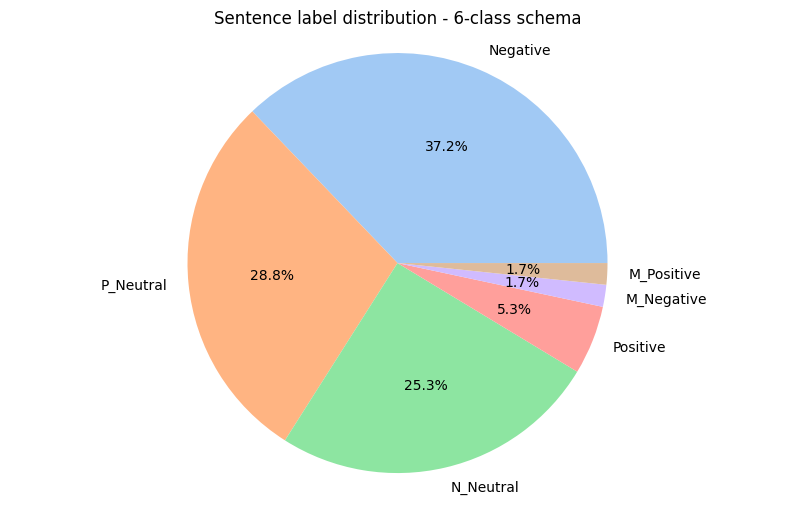

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette('pastel')

plt.figure(figsize=(10,6))
plt.pie(label_percentage, labels=label_percentage.index, colors=palette, autopct='%1.1f%%')
plt.title('Sentence label distribution - 6-class schema')
plt.axis('equal')
plt.savefig('../Figures/Labels_6class.png', dpi=300)
plt.show()

In [14]:
df['final_tag3'] = df['final_tag'].map(mapping_3class)
df['final_tag3'].unique()

array(['Neutral', 'Negative', 'Positive'], dtype=object)

In [19]:
label3 = df['final_tag3'].value_counts()
label3

final_tag3
Neutral     1409
Negative    1010
Positive     181
Name: count, dtype: int64

In [20]:
sent_percentage = (label3 / label3.sum()) *100
sent_percentage

final_tag3
Neutral     54.192308
Negative    38.846154
Positive     6.961538
Name: count, dtype: float64

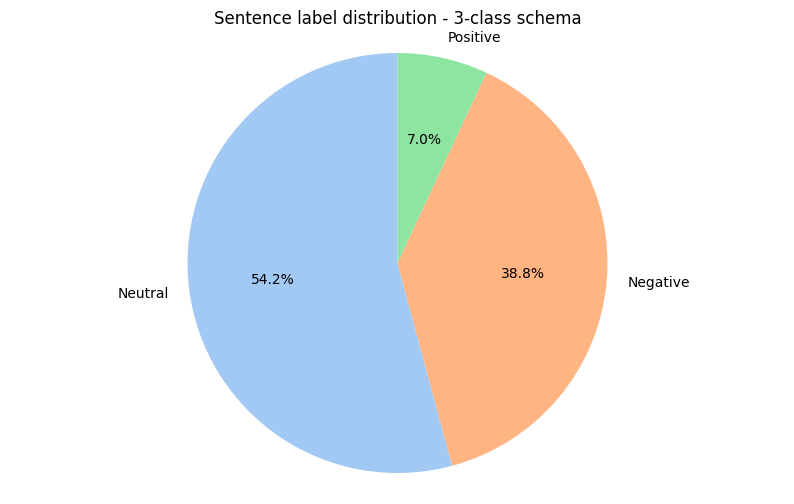

In [23]:
plt.figure(figsize=(10, 6))
plt.pie(sent_percentage, labels=sent_percentage.index, colors=palette, startangle=90, autopct='%1.1f%%')
plt.title('Sentence label distribution - 3-class schema')
plt.axis('equal')
plt.savefig('../Figures/Labels_3class.png', dpi=300)
plt.show()